# Lab 02 · Parte 1 — Teoría de conjuntos con plantillas de fútbol (Python)

Disponemos de **40 archivos CSV**: las plantillas de las últimas **20 temporadas** (2004-05 a 2023-24) de dos clubes.

| Conjunto | Club | Archivos |
|---|---|---|
| **A** | Atlético de Madrid | `atletico_AAAA-AA.csv` |
| **B** | FC Barcelona | `barcelona_AAAA-AA.csv` |

Cada archivo tiene una única columna, `jugador`. Un jugador que estuvo varias temporadas aparece en varios archivos, así que primero hay que **eliminar duplicados** para que cada club sea un conjunto en sentido matemático: cada elemento aparece una sola vez.

## Preparación

Los CSV están montados en el contenedor en `/home/jovyan/datasets`. Si el notebook se ejecuta fuera de Docker, se usa la ruta relativa del repositorio.

In [1]:
from pathlib import Path
import unicodedata

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

DATA_DIR = Path("/home/jovyan/datasets/lab02/futbol_data")
if not DATA_DIR.exists():
    DATA_DIR = Path("../../datasets/lab02/futbol_data")

print(DATA_DIR.resolve(), "->", len(list(DATA_DIR.glob("*.csv"))), "archivos CSV")

/home/jovyan/datasets/lab02/futbol_data -> 40 archivos CSV


## Parte 1. Construcción de los conjuntos

### 1–3. Leer los 20 archivos de cada club y eliminar duplicados

`glob` encuentra automáticamente los archivos de cada club. Se leen con `encoding="utf-8-sig"` porque los CSV llevan BOM: sin eso, la cabecera se leería como `\ufeffjugador`. Al convertir la columna en `set`, los duplicados desaparecen.

In [2]:
def leer_club(prefijo):
    """Lee todas las temporadas de un club y devuelve (filas totales, conjunto de jugadores)."""
    archivos = sorted(DATA_DIR.glob(f"{prefijo}_*.csv"))
    assert len(archivos) == 20, f"Se esperaban 20 archivos de {prefijo}, hay {len(archivos)}"
    plantillas = pd.concat(
        (pd.read_csv(f, encoding="utf-8-sig") for f in archivos),
        ignore_index=True,
    )
    jugadores = plantillas["jugador"].str.strip()
    return len(jugadores), set(jugadores)


filas_a, club_a = leer_club("atletico")   # Club A
filas_b, club_b = leer_club("barcelona")  # Club B

print(f"Atlético : {filas_a} filas -> {len(club_a)} jugadores únicos")
print(f"Barcelona: {filas_b} filas -> {len(club_b)} jugadores únicos")

Atlético : 264 filas -> 58 jugadores únicos
Barcelona: 287 filas -> 53 jugadores únicos


### 4. ¿Cuántos jugadores únicos ha tenido cada club?

### 5. Conjuntos ordenados alfabéticamente

`sorted()` compara códigos Unicode y manda los nombres con tilde al final («Álvaro» detrás de «Zé»). Para un orden alfabético real se ordena con una clave **sin tildes y en minúsculas**.

In [3]:
def clave_alfabetica(nombre):
    sin_tildes = unicodedata.normalize("NFKD", nombre).encode("ascii", "ignore").decode()
    return sin_tildes.casefold()


def ordenar(conjunto):
    return sorted(conjunto, key=clave_alfabetica)


resumen = pd.DataFrame(
    {"Club": ["Atlético (A)", "Barcelona (B)"], "Jugadores únicos": [len(club_a), len(club_b)]}
)
resumen

,Club,Jugadores únicos
0,Atlético (A),58
1,Barcelona (B),53


In [4]:
print(f"Club A — Atlético ({len(club_a)} jugadores)\n")
print(", ".join(ordenar(club_a)))

Club A — Atlético (58 jugadores)

Adrián López, Álvaro Domínguez, Álvaro Morata, Ángel Correa, Antoine Griezmann, Antonio López, Arda Turan, Axel Witsel, César Azpilicueta, Colsa, David de Gea, David Villa, Diego Forlán, Diego Godín, Fernando Torres, Filipe Luís, García Calvo, Giménez, Grzegorz Rasiak, Ibagaza, Jan Oblak, João Félix, John Heitinga, Jorge Larena, José Manuel Jurado, Juan Valera, Juan Velasco, Juanfran Torres, Koke Resurrección, Leo Franco, Luis Perea, Marco Babić, Marcos Llorente, Mario Suárez, Matheus Cunha, Maxi Rodríguez, Memphis Depay, Miranda, Nahuel Molina, Oliver Torres, Pablo Ibáñez, Paulo Assunção, Peter Luccin, Raúl García, Renan Lodi, Richard Núñez, Rodrigo de Paul, Salva Ballesta, Saúl Ñíguez, Sergi Barjuán, Sergio Agüero, Simão Sabrosa, Stefan Savić, Thiago Motta, Thibaut Courtois, Thomas Partey, Tiago Mendes, Yannick Carrasco


In [5]:
print(f"Club B — Barcelona ({len(club_b)} jugadores)\n")
print(", ".join(ordenar(club_b)))

Club B — Barcelona (53 jugadores)

Albert Jorquera, Alexis Sánchez, Andrés Iniesta, Ansu Fati, Antoine Griezmann, Carles Puyol, Cesc Fàbregas, Dani Alves, David Villa, Deco, Edmilson, Éric Abidal, Fernando Navarro, Ferran Torres, Frenkie de Jong, Gabriel Milito, Gavi, Gerard Piqué, Giovanni van Bronckhorst, Henrik Larsson, İlkay Gündoğan, Ivan Rakitic, Javier Mascherano, João Cancelo, João Félix, Jordi Alba, Jules Koundé, Juliano Belletti, Lamine Yamal, Lionel Messi, Ludovic Giuly, Luis Suárez, Marc-André ter Stegen, Neymar Jr, Oleguer Presas, Ousmane Dembélé, Pedri, Pedro Rodríguez, Rafa Márquez, Raphinha, Robert Lewandowski, Ronald Araújo, Ronaldinho, Samuel Eto'o, Samuel Umtiti, Sergio Busquets, Seydou Keita, Sylvinho, Thierry Henry, Víctor Valdés, Xavi Hernández, Yaya Touré, Zlatan Ibrahimović


## Parte 2. Operaciones con conjuntos

### 1. Unión $A \cup B$: jugadores que han pasado por alguno de los dos clubes

In [6]:
union = club_a | club_b          # equivalente: club_a.union(club_b)
universo = union
print(f"Jugadores diferentes en alguno de los dos clubes: {len(union)}")

Jugadores diferentes en alguno de los dos clubes: 108


### 2. Intersección $A \cap B$: jugadores que han estado en ambos clubes

In [7]:
interseccion = club_a & club_b   # club_a.intersection(club_b)
print(f"{len(interseccion)} jugadores en ambos clubes:")
for jugador in ordenar(interseccion):
    print(" -", jugador)

3 jugadores en ambos clubes:
 - Antoine Griezmann
 - David Villa
 - João Félix


### 3. Diferencia $A \setminus B$: jugadores que solo han jugado en el Atlético

In [8]:
solo_a = club_a - club_b         # club_a.difference(club_b)
print(f"{len(solo_a)} jugadores solo en el Atlético:\n")
print(", ".join(ordenar(solo_a)))

55 jugadores solo en el Atlético:

Adrián López, Álvaro Domínguez, Álvaro Morata, Ángel Correa, Antonio López, Arda Turan, Axel Witsel, César Azpilicueta, Colsa, David de Gea, Diego Forlán, Diego Godín, Fernando Torres, Filipe Luís, García Calvo, Giménez, Grzegorz Rasiak, Ibagaza, Jan Oblak, John Heitinga, Jorge Larena, José Manuel Jurado, Juan Valera, Juan Velasco, Juanfran Torres, Koke Resurrección, Leo Franco, Luis Perea, Marco Babić, Marcos Llorente, Mario Suárez, Matheus Cunha, Maxi Rodríguez, Memphis Depay, Miranda, Nahuel Molina, Oliver Torres, Pablo Ibáñez, Paulo Assunção, Peter Luccin, Raúl García, Renan Lodi, Richard Núñez, Rodrigo de Paul, Salva Ballesta, Saúl Ñíguez, Sergi Barjuán, Sergio Agüero, Simão Sabrosa, Stefan Savić, Thiago Motta, Thibaut Courtois, Thomas Partey, Tiago Mendes, Yannick Carrasco


### 4. Diferencia simétrica $A \triangle B$: jugadores que han jugado en uno solo de los dos clubes

In [9]:
diferencia_simetrica = club_a ^ club_b   # club_a.symmetric_difference(club_b)
solo_b = club_b - club_a
print(f"{len(diferencia_simetrica)} jugadores exclusivos de un único club "
      f"({len(solo_a)} del Atlético + {len(solo_b)} del Barcelona)")

105 jugadores exclusivos de un único club (55 del Atlético + 50 del Barcelona)


### 5. Complemento de la intersección respecto al universo $U = A \cup B$

$(A \cap B)^c = U \setminus (A \cap B)$: jugadores que **no** han pasado por ambos clubes.

In [10]:
complemento_interseccion = universo - interseccion
print(f"{len(complemento_interseccion)} jugadores no han pasado por ambos clubes")
print("¿Coincide con la diferencia simétrica?", complemento_interseccion == diferencia_simetrica)

105 jugadores no han pasado por ambos clubes
¿Coincide con la diferencia simétrica? True


## Parte 3. Análisis de resultados

In [11]:
porcentaje_ambos = len(interseccion) / len(universo) * 100
print(f"1. Han jugado en ambos clubes: {len(interseccion)} de {len(universo)} "
      f"= {porcentaje_ambos:.2f} % del universo")

exclusivos = {"Atlético": len(solo_a), "Barcelona": len(solo_b)}
club_mas_exclusivos = max(exclusivos, key=exclusivos.get)
print(f"2. Jugadores exclusivos: {exclusivos} -> más exclusivos: {club_mas_exclusivos}")

# Comprobación del principio de inclusión-exclusión
assert len(union) == len(club_a) + len(club_b) - len(interseccion)

1. Han jugado en ambos clubes: 3 de 108 = 2.78 % del universo
2. Jugadores exclusivos: {'Atlético': 55, 'Barcelona': 50} -> más exclusivos: Atlético


## Parte 4. Ampliación: diagrama de Venn

La imagen no incluye `matplotlib-venn`, así que el diagrama se dibuja con dos círculos de `matplotlib`. Los nombres de la intersección se muestran dentro de la zona común.

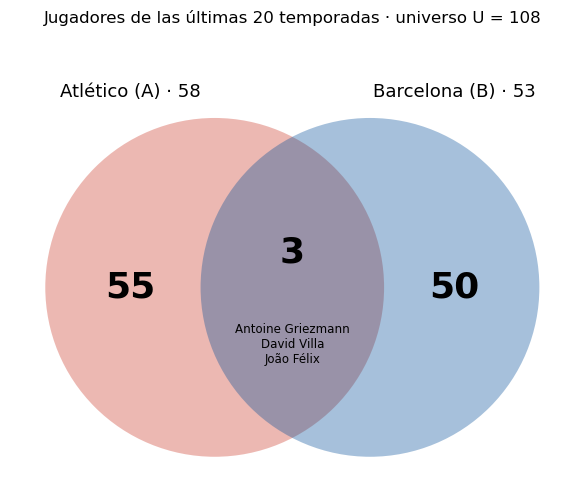

In [12]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.add_patch(Circle((-0.55, 0), 1.2, color="#CB3524", alpha=0.35, lw=0))
ax.add_patch(Circle((0.55, 0), 1.2, color="#004D98", alpha=0.35, lw=0))

ax.text(-1.15, 0, len(solo_a), ha="center", va="center", fontsize=26, weight="bold")
ax.text(1.15, 0, len(solo_b), ha="center", va="center", fontsize=26, weight="bold")
ax.text(0, 0.25, len(interseccion), ha="center", va="center", fontsize=26, weight="bold")
ax.text(0, -0.25, "\n".join(ordenar(interseccion)), ha="center", va="top", fontsize=8.5)

ax.text(-1.15, 1.35, f"Atlético (A) · {len(club_a)}", ha="center", fontsize=13)
ax.text(1.15, 1.35, f"Barcelona (B) · {len(club_b)}", ha="center", fontsize=13)
ax.set_title(f"Jugadores de las últimas 20 temporadas · universo U = {len(universo)}", pad=28)
ax.set_xlim(-2, 2)
ax.set_ylim(-1.4, 1.6)
ax.set_aspect("equal")
ax.axis("off")
plt.show()

## Conclusiones

- Por el **Atlético** han pasado **58** jugadores distintos y por el **Barcelona**, **53**.
- El universo (unión) tiene **108** jugadores, y solo **3** han jugado en ambos clubes: Antoine Griezmann, David Villa y João Félix. Son el **2,78 %** del universo.
- El Atlético tiene más jugadores exclusivos (**55** frente a **50**).
- El complemento de la intersección dentro del universo coincide con la **diferencia simétrica** (105 jugadores): $U \setminus (A \cap B) = A \triangle B$ cuando $U = A \cup B$.
- Comprobación de cardinales: $|A \cup B| = |A| + |B| - |A \cap B| = 58 + 53 - 3 = 108$.